In [330]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import pyiga

import scipy
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import csc_matrix, csr_matrix, coo_matrix
from scipy.sparse.linalg import aslinearoperator

np.set_printoptions(linewidth=100000)
np.set_printoptions(precision=5)

from pyiga import bspline, assemble, vform, geometry, vis, solvers, topology, bspline_cy


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [331]:
geo = geometry.quarter_annulus(1.0,2)

In [332]:
kvs = 2* (bspline.make_knots(3,0,1,5),)

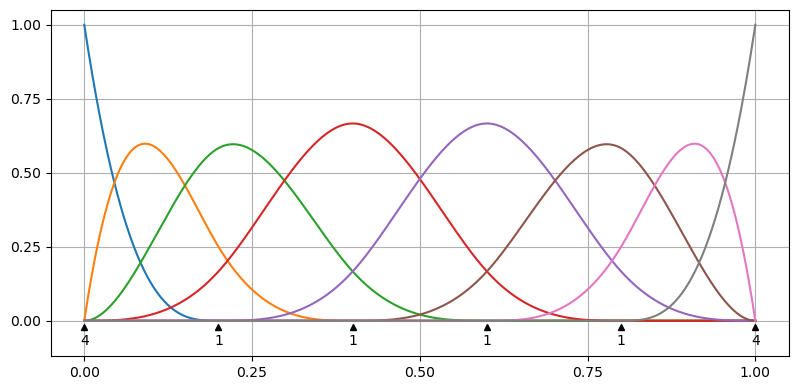

In [347]:
fig, ax = plt.subplots(figsize=(8, 4))
kvs[0].plot(ax=ax)
ax.set_xticks([0,0.25,0.5,0.75,1.0])
ax.set_yticks([0,0.25,0.5,0.75,1.0])
plt.savefig('/home/wolfman/Pictures/Bsplines_p3N5.png',bbox_inches='tight',dpi=300,pad_inches=0)

In [339]:
kvs[0].kv

array([0. , 0. , 0. , 0. , 0.2, 0.4, 0.6, 0.8, 1. , 1. , 1. , 1. ])

In [260]:
kvs[0].numdofs

8

In [340]:
i = 3
j = 3
phi = bspline.BSplineFunc(kvs, np.eye(1,64,i*8+3).ravel())
phix = bspline.BSplineFunc(kvs[0], np.eye(1,8,i).ravel())
phiy = bspline.BSplineFunc(kvs[1], np.eye(1,8,j).ravel())

In [341]:
# parameter domain
N = 4
nu, nv = 6+(2**N-1)*5, 6+(2**N-1)*5
u = np.linspace(0, 1, nu)
v = np.linspace(0, 1, nv)

U, V = np.meshgrid(u, v, indexing="ij")
Z = phi(u,v)
Zx = phix(u)
Zy = phiy(v)

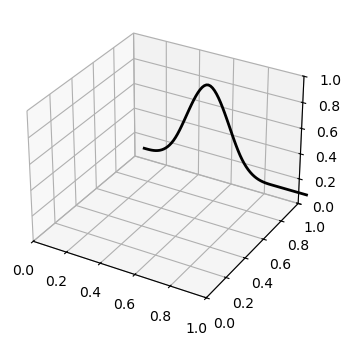

In [342]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111,projection="3d")

ax.plot3D(
    u, np.ones(len(u))+0.1, Zx,
    linewidth=2,
    color="black"
)
ax.set_xlim(u.min(), u.max())
ax.set_ylim(0, 1)
ax.set_zlim(0, 1)

plt.show()

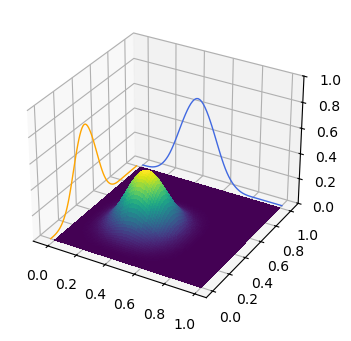

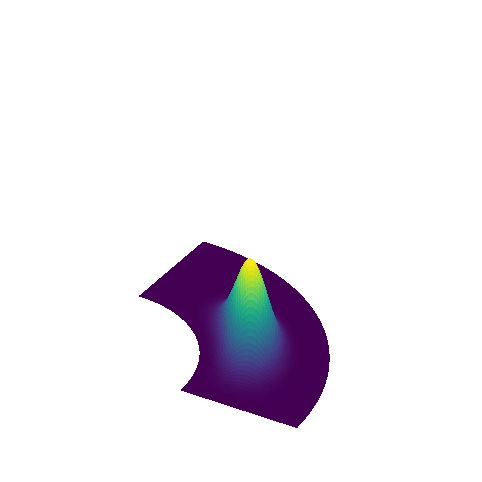

In [346]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa
from PIL import Image

fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    U, V, Z,
    cmap="viridis",
    shade=False,
    linewidth=0,
    antialiased=False,
    rstride=1,
    cstride=1
)
ax.plot3D(
    u, np.ones(len(u))+0.03, Zx,
    linewidth=1,
    color="royalblue"
)
ax.plot3D(
    np.zeros(len(v))-0.03, v, Zy,
    linewidth=1,
    color="orange"
)
#ax.set_box_aspect((1, 1, 0.3))
#ax.set_axis_off()
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.set_zticklabels([])
ax.set_zlim(0, 1)      # cutoff at z = 0.5
surf.set_clip_on(True)  # actually clip the surface

u_mesh = kvs[0].mesh
v_mesh = kvs[1].mesh

plt.savefig('/home/wolfman/Pictures/2DBasis.png',bbox_inches='tight',dpi=300,pad_inches=0)
#img = Image.open('/home/wolfman/Pictures/2DBasis.png')
#img = img.crop((0, int(0.2*img.size[1]), img.size[0], img.size[1]))
#img.save('/home/wolfman/Pictures/2DBasis.png')
plt.show()

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

X,Y = geo(u,v)[:,:,0], geo(u,v)[:,:,1]

#tri = Triangulation(X.ravel(), Y.ravel())
ax.plot_surface(
    X, Y, Z,
    cmap="viridis",
    shade=False,
    linewidth=0,
    antialiased=False,
    rstride=1,
    cstride=1
)
ax.set_axis_off()
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])
ax.set_zlim(0, 1)

plt.savefig('/home/wolfman/Pictures/2DBasis_transformation.png',bbox_inches='tight',dpi=300)
img = Image.open('/home/wolfman/Pictures/2DBasis_transformation.png')
img = img.crop((0, int(0.4*img.size[1]), img.size[0], img.size[1]))
img.save('/home/wolfman/Pictures/2DBasis_transformation.png')
plt.show()

In [325]:
27%7

6

In [148]:
z = phi(0.5, v)

In [150]:
z.shape

(100,)

In [161]:
geo(np.array([0,0.5,1.0]),0.5)

array([[0.70711, 0.70711],
       [1.06066, 1.06066],
       [1.41421, 1.41421]])

In [112]:
U.shape

(100, 100)

In [107]:
Y.shape

(100, 2)

In [97]:
geo(u,v).shape

(100, 100, 2)

In [99]:
U.shape

(100, 100)

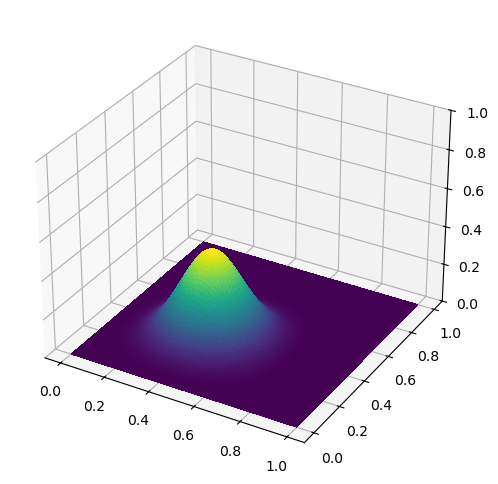

In [93]:
from matplotlib.tri import Triangulation

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
tri = Triangulation(U.ravel(), V.ravel())

ax.plot_trisurf(
    tri,
    Z.ravel(),
    cmap="viridis",
    linewidth=0,
    antialiased=False,
    shade=False
)
ax.set_zlim(0, 1)
plt.show()

In [86]:
u_curve

array([0. , 0.2, 0.4, 0.6, 0.8, 1. ])

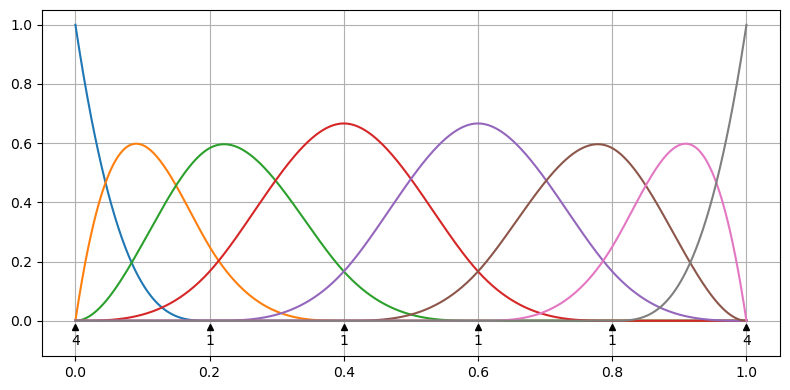

In [64]:
kvs[0].plot()

In [43]:
np.eye(1,64,3).ravel()

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [14]:
np.eye

<function numpy.eye(N, M=None, k=0, dtype=<class 'float'>, order='C', *, device=None, like=None)>